In [51]:
import numpy as np
import pandas as pd
import librosa
import xml.etree.ElementTree as ET
import os

string_num_mapping = {
    1 : 'low-E',
    2 : 'A',
    3 : 'D',
    4 : 'G',
    5 : 'B',
    6 : 'high-E'
}

# Extract Pitch, String, and Fret information from Single Note Samples

In [91]:
annot_dir = 'Guitar-Data/IDMT-SMT-GUITAR_V2/dataset1/Fender Strat Clean Neck SC/annotation/'
annot_paths = os.listdir(annot_dir)
try:
    annot_paths.remove('.ipynb_checkpoints')
except:
    pass

In [90]:
def extract_labels(xml_dir, xml_path):
    note_labels = {}
    
    tree = ET.parse(xml_dir+xml_path)
    root = tree.getroot()
    
    pitch = librosa.midi_to_note(int(root.find('.//pitch').text))
    string = root.find('.//stringNumber').text
    fret = root.find('.//fretNumber').text

    note_labels['pitch'] = pitch
    note_labels['string'] = string
    note_labels['fret'] = fret

    return note_labels

labels = {annot_path[:-4] : extract_labels(annot_dir, annot_path) for annot_path in annot_paths}
labels

{'G53-60405-1111-00045': {'pitch': 'C4', 'string': '4', 'fret': '5'},
 'G53-65601-1111-00067': {'pitch': 'F4', 'string': '6', 'fret': '1'},
 'G53-51301-1111-00028': {'pitch': 'D♯3', 'string': '3', 'fret': '1'},
 'G53-58308-1111-00035': {'pitch': 'A♯3', 'string': '3', 'fret': '8'},
 'G53-62503-1111-00056': {'pitch': 'D4', 'string': '5', 'fret': '3'},
 'G53-59309-1111-00036': {'pitch': 'B3', 'string': '3', 'fret': '9'},
 'G53-64600-1111-00066': {'pitch': 'E4', 'string': '6', 'fret': '0'},
 'G53-46106-1111-00007': {'pitch': 'A♯2', 'string': '1', 'fret': '6'},
 'G53-65410-1111-00050': {'pitch': 'F4', 'string': '4', 'fret': '10'},
 'G53-52302-1111-00029': {'pitch': 'E3', 'string': '3', 'fret': '2'},
 'G53-60501-1111-00054': {'pitch': 'C4', 'string': '5', 'fret': '1'},
 'G53-62407-1111-00047': {'pitch': 'D4', 'string': '4', 'fret': '7'},
 'G53-56401-1111-00041': {'pitch': 'G♯3', 'string': '4', 'fret': '1'},
 'G53-68509-1111-00062': {'pitch': 'G♯4', 'string': '5', 'fret': '9'},
 'G53-44104-11

# Extract Audio Features from Single Note Samples

In [92]:
sample_dir = 'Guitar-Data/IDMT-SMT-GUITAR_V2/dataset1/Fender Strat Clean Neck SC/audio/'
sample_paths = os.listdir(sample_dir)
try:
    sample_paths.remove('.ipynb_checkpoints')
except:
    pass

In [87]:
from librosa import display
import matplotlib.pyplot as plt

y, sr = librosa.load(sample_dir+sample_paths[0])

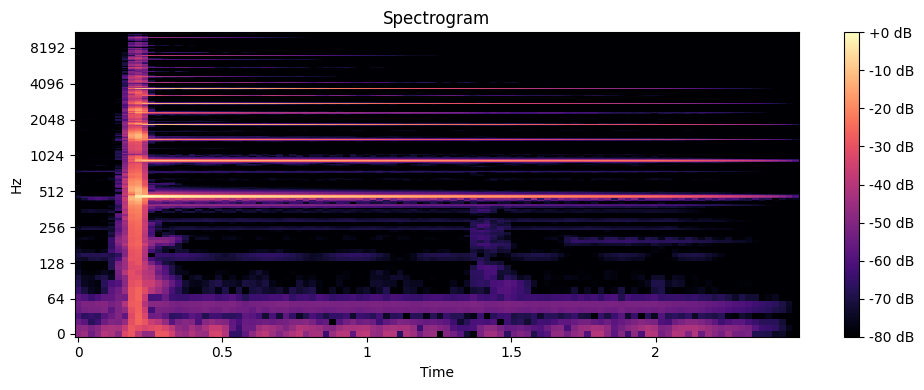

In [89]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()